# Caso MLP - Multilayer Perceptron

- Contexto: una empresa de servicios de suscripción de streaming quiere predecir si un usuario cancelará su suscripción (churn) el proximo mes para poder lanzar una campaña de retención. 
- Objetivo: Crear un modelo de clasificación binaria utilizando un Perceptron Multicapa (MLP)   que identifique a los usuarios en riesgo de abandono basándose en su comportamiento de uso y edad.  


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)

In [17]:
data_dict = {
    "Edad": [
        21, 23, 20, 24, 21, 95, 33, 44, 18, 59,
        21, 23, 56, 40, 31, 20, 31, 38, 48, 25,
        50, 48, 51, 19, 41, 20, 29, 39, 18, 45,
        23, 51, 57, 30, 28, 42, 38, 30, 28, 50,
        53, 31, 38, 26, 36, 18, 26, 41, 46, 54,
        40, 21, 33, 53, 54, 40, 33, 41, 42, 53,
        28, 31, 22, 19, 30, 22, 23, 35, 59, 56,
        19, 55, 35, 31, 40, 42, 25, 41, 33, 33,
        57, 43, 27, 47, 53, 29, 21, 49, 35, 30,
        31, 18, 55, 47, 28, 54, 22, 29, 29, 30
    ],

    "Meses_Contrato": [
        2, 1, 3, 2, 2, 2, 8, 8, 1, 33,
        5, 2, 22, 6, 12, 1, 9, 11, 11, 2,
        18, 14, 21, 1, 13, 120, 2, 7, 1, 11,
        1, 17, 37, 8, 1, 12, 14, 2, 2, 17,
        21, 12, 15, 2, 6, 1, 1, 15, 11, 24,
        1, 5, 9, 22, 22, 6, 4, 13, 15, 17,
        1, 13, 2, 1, 2, 1, 3, 4, 38, 22,
        1, 25, 6, 10, 6, 8, 1, 13, 8, 4,
        24, 10, 1, 10, 22, 4, 3, 19, 6, 3,
        12, 1, 24, 14, 2, 23, 2, 4, 4, 8
    ],

    "Horas_Al_Mes": [
        43, 11, 40, 37, 33, 10, 77, 98, 21, 169,
        32, 11, 171, 71, 79, 15, 87, 88, 111, 14,
        113, 82, 142, 0, 94, 750, 41, 73, 0, 107,
        0, 138, 168, 65, 34, 102, 103, 17, 41, 119,
        155, 101, 88, 40, 93, 21, 0, 89, 101, 146,
        5, 34, 53, 111, 132, 63, 76, 82, 90, 122,
        17, 72, 33, 24, 31, 2, 46, 75, 169, 162,
        0, 143, 70, 73, 90, 116, 22, 85, 67, 86,
        149, 90, 8, 93, 129, 95, 36, 137, 81, 16,
        91, 16, 158, 123, 56, 138, 54, 84, 88, 69
    ],

    "Abandono": [
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
        0, 1, 1, 0, 1, 0, 1, 0, 0, 0
    ]
}

# Analisis EDA

In [18]:
# Crear el DataFrame
df = pd.DataFrame(data_dict)
df.head()
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Edad            100 non-null    int64
 1   Meses_Contrato  100 non-null    int64
 2   Horas_Al_Mes    100 non-null    int64
 3   Abandono        100 non-null    int64
dtypes: int64(4)
memory usage: 3.2 KB


,count,mean,std,min,25%,50%,75%,max
Edad,100.0,36.20,13.488491,18.0,25.75,33.0,46.25,95.0
Meses_Contrato,100.0,10.49,13.998193,1.0,2.00,7.5,14.00,120.0
Horas_Al_Mes,100.0,81.03,82.612452,0.0,33.75,78.0,104.00,750.0
Abandono,100.0,0.33,0.472582,0.0,0.00,0.0,1.00,1.0


In [19]:
# Calidad de datos: nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
Edad              0
Meses_Contrato    0
Horas_Al_Mes      0
Abandono          0
dtype: int64

Filas duplicadas: 2


In [20]:
# Eliminamos duplicados exactos (no aportan información nueva al modelo)
df = df.drop_duplicates().reset_index(drop=True)
print("Nueva forma del dataset:", df.shape)

Nueva forma del dataset: (98, 4)


C:\Users\borja\AppData\Local\Temp\ipykernel_5608\254646609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Abandono", data=df, palette="Set2", ax=ax)


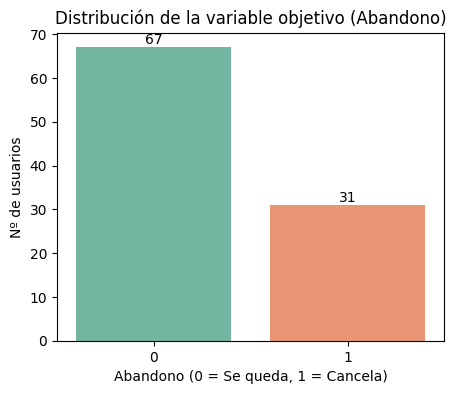

Abandono
0    0.68
1    0.32
Name: proportion, dtype: float64


In [21]:
# Balance de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Abandono", data=df, palette="Set2", ax=ax)
ax.set_title("Distribución de la variable objetivo (Abandono)")
ax.set_xlabel("Abandono (0 = Se queda, 1 = Cancela)")
ax.set_ylabel("Nº de usuarios")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['Abandono'].value_counts(normalize=True).round(2))

C:\Users\borja\AppData\Local\Temp\ipykernel_5608\473087878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Abandono", y=col, data=df, palette="Set2", ax=ax)
C:\Users\borja\AppData\Local\Temp\ipykernel_5608\473087878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Abandono", y=col, data=df, palette="Set2", ax=ax)
C:\Users\borja\AppData\Local\Temp\ipykernel_5608\473087878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Abandono", y=col, data=df, palette="Set2", ax=ax)


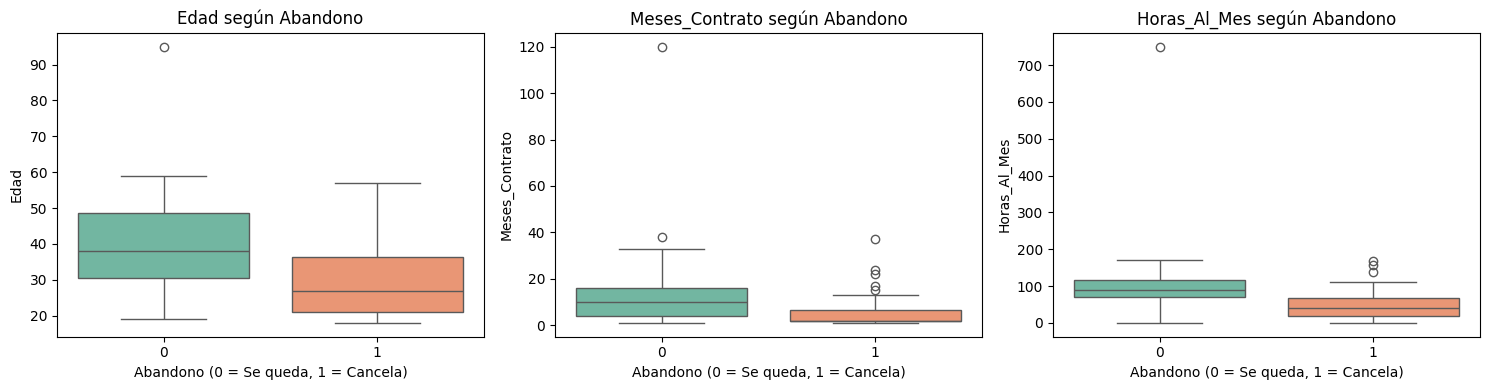

In [22]:
# Distribuciones segmentadas por Abandono
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Edad", "Meses_Contrato", "Horas_Al_Mes"]):
    sns.boxplot(x="Abandono", y=col, data=df, palette="Set2", ax=ax)
    ax.set_title(f"{col} según Abandono")
    ax.set_xlabel("Abandono (0 = Se queda, 1 = Cancela)")
plt.tight_layout()
plt.show()

## Creación del Modelo

In [23]:
# Separar X e y

X = df[["Edad", "Meses_Contrato", "Horas_Al_Mes"]]
y = df["Abandono"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

In [25]:
# Estandarización

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Construcción del modelo

mlp = MLPClassifier(
    hidden_layer_sizes=(2,2),
    max_iter=1000,
    random_state=42
)


# no por meter más capas o neuronas mejora el modelo

In [27]:
mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(2, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [28]:
# Predicciones

y_pred = mlp.predict(X_test_scaled)
y_scores = mlp.predict_proba(X_test_scaled)[:,1]

# Evaluar
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Se queda", "Cancela"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — Predicción de Abandono")
plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        13
           1       0.00      0.00      0.00         7

    accuracy                           0.65        20
   macro avg       0.33      0.50      0.39        20
weighted avg       0.42      0.65      0.51        20



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

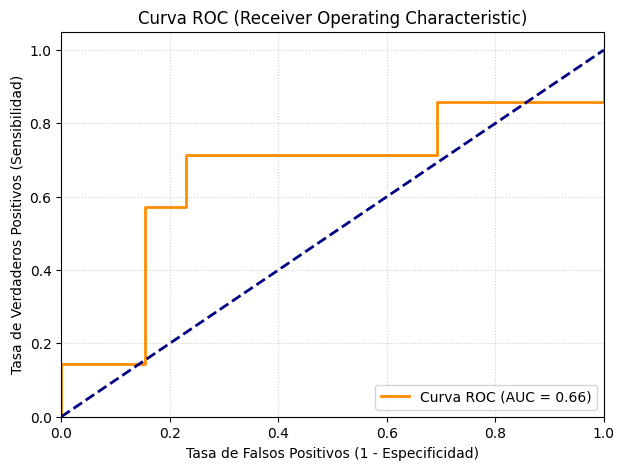

In [30]:
# Calcular la curva ROC y el área bajo la curva (AUC)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Curva ROC (AUC = {roc_auc:.2f})"
)

# Línea de referencia (clasificador aleatorio)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC (Receiver Operating Characteristic)")

plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()